#Alina Shrestha
#Worksheet08

# Text Classification using Machine Learning Models

---




:### 📝 Instructions: Trump Tweet Sentiment Classification

1. **Load the Dataset**  
   Load the dataset named `"trump_tweet_sentiment_analysis.csv"` using `pandas`. Ensure the dataset contains at least two columns: `"text"` and `"label"`.

2. **Text Cleaning and Tokenization**  
   Apply a text preprocessing pipeline to the `"text"` column. This should include:
   - Lowercasing the text  
   - Removing URLs, mentions, punctuation, and special characters  
   - Removing stopwords  
   - Tokenization (optional: stemming or lemmatization)
   - "Complete the above function"

3. **Train-Test Split**  
   Split the cleaned and tokenized dataset into **training** and **testing** sets using `train_test_split` from `sklearn.model_selection`.

4. **TF-IDF Vectorization**  
   Import and use the `TfidfVectorizer` from `sklearn.feature_extraction.text` to transform the training and testing texts into numerical feature vectors.

5. **Model Training and Evaluation**  
   Import **Logistic Regression** (or any machine learning model of your choice) from `sklearn.linear_model`. Train it on the TF-IDF-embedded training data, then evaluate it using the test set.  
   - Print the **classification report** using `classification_report` from `sklearn.metrics`.


#1.load the dataset

In [ ]:
from google.colab import files
uploaded = files.upload()


import pandas as pd

# Load dataset
df = pd.read_csv("news_category.csv")

# Show first 5 rows

print(df.head())
print(df.columns)

Saving news_category.csv to news_category (2).csv
                                            headline        category
0  How A New Documentary Captures The Complexity ...  CULTURE & ARTS
1  Twitch Bans Gambling Sites After Streamer Scam...            TECH
2  'Reboot' Is A Clever And Not Too Navel-Gazey L...  CULTURE & ARTS
3  Maury Wills, Base-Stealing Shortstop For Dodge...          SPORTS
4  Las Vegas Aces Win First WNBA Title, Chelsea G...          SPORTS
Index(['headline', 'category'], dtype='object')


# Build a Text Cleaning Pipeline

1.   List item
2.   List item



#Text cleaning

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer

nltk.download('stopwords')
nltk.download('wordnet')

def text_cleaning_pipeline(text, rule="lemmatize"):

    text = text.lower()

    # remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # remove mentions (@user)
    text = re.sub(r'@\w+', '', text)

    # remove punctuation & special characters
    text = re.sub(r'[^a-z\s]', '', text)

    # tokenize
    tokens = text.split()

    # remove stopwords
    stop_words = set(stopwords.words('english'))
    tokens = [w for w in tokens if w not in stop_words]

    # stemming / lemmatization
    if rule == "lemmatize":
        lemmatizer = WordNetLemmatizer()
        tokens = [lemmatizer.lemmatize(w) for w in tokens]

    elif rule == "stem":
        stemmer = PorterStemmer()
        tokens = [stemmer.stem(w) for w in tokens]

    return " ".join(tokens)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


#Apply cleaning

In [ ]:
df['clean_text'] = df['headline'].apply(text_cleaning_pipeline)

#what are the columns

In [ ]:
print(df.columns)

Index(['headline', 'category'], dtype='object')


#Train-test split

In [ ]:
from sklearn.model_selection import train_test_split

X = df['headline']
y = df['category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Apply Cleaning BEFORE TF-IDF

In [ ]:
df['clean_text'] = df['headline'].apply(text_cleaning_pipeline)

X = df['clean_text']
y = df['category']

#Split again

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

#Model training

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print(classification_report(y_test, y_pred))

                precision    recall  f1-score   support

CULTURE & ARTS       0.94      0.63      0.76       224
     EDUCATION       0.90      0.62      0.73       193
         MONEY       0.85      0.76      0.80       338
        SPORTS       0.81      0.98      0.89      1020
          TECH       0.88      0.77      0.82       430

      accuracy                           0.84      2205
     macro avg       0.88      0.75      0.80      2205
  weighted avg       0.85      0.84      0.83      2205



#Prediction and  evaluation

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8390022675736961
                precision    recall  f1-score   support

CULTURE & ARTS       0.94      0.63      0.76       224
     EDUCATION       0.90      0.62      0.73       193
         MONEY       0.85      0.76      0.80       338
        SPORTS       0.81      0.98      0.89      1020
          TECH       0.88      0.77      0.82       430

      accuracy                           0.84      2205
     macro avg       0.88      0.75      0.80      2205
  weighted avg       0.85      0.84      0.83      2205



#check the accuracy

In [ ]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8390022675736961


#confusion matrix

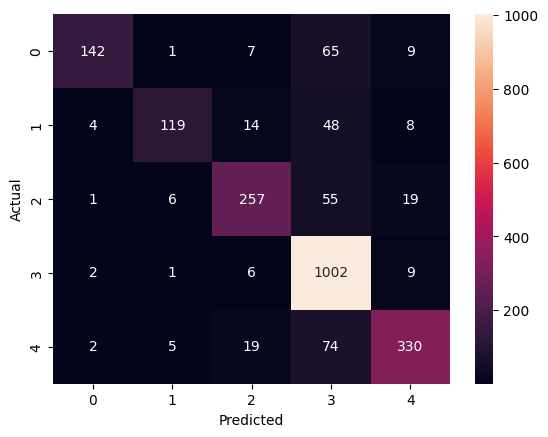

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
sample = ["I am walking peacefully."]

clean_sample = text_cleaning_pipeline(sample[0])
vector_sample = vectorizer.transform([clean_sample])

prediction = model.predict(vector_sample)

print("Prediction:", prediction[0])

Prediction: SPORTS


#validation and the confusion  matrix

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8390022675736961
[[ 142    1    7   65    9]
 [   4  119   14   48    8]
 [   1    6  257   55   19]
 [   2    1    6 1002    9]
 [   2    5   19   74  330]]


#Different model (Naive Bayes)

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)

nb_pred = nb.predict(X_test_tfidf)

print("NB Accuracy:", accuracy_score(y_test, nb_pred))
print(classification_report(y_test, nb_pred))

NB Accuracy: 0.8068027210884354
                precision    recall  f1-score   support

CULTURE & ARTS       0.96      0.52      0.67       224
     EDUCATION       0.95      0.41      0.57       193
         MONEY       0.84      0.75      0.79       338
        SPORTS       0.77      0.99      0.86      1020
          TECH       0.84      0.74      0.79       430

      accuracy                           0.81      2205
     macro avg       0.87      0.68      0.74      2205
  weighted avg       0.83      0.81      0.79      2205



#SVM

In [ ]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train_tfidf, y_train)

svm_pred = svm.predict(X_test_tfidf)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

SVM Accuracy: 0.8571428571428571
                precision    recall  f1-score   support

CULTURE & ARTS       0.83      0.71      0.76       224
     EDUCATION       0.82      0.70      0.76       193
         MONEY       0.81      0.82      0.81       338
        SPORTS       0.89      0.95      0.92      1020
          TECH       0.85      0.81      0.83       430

      accuracy                           0.86      2205
     macro avg       0.84      0.80      0.82      2205
  weighted avg       0.86      0.86      0.85      2205



#Final testing

In [ ]:
tests = [
    "Government announces new financial policy",
    "Stock market drops sharply today",
    "Trump speaks at rally in New York"
]

for t in tests:
    cleaned = text_cleaning_pipeline(t)
    vec = vectorizer.transform([cleaned])
    print(t, "=>", model.predict(vec)[0])

Government announces new financial policy => MONEY
Stock market drops sharply today => MONEY
Trump speaks at rally in New York => SPORTS


In [ ]:
sample = "Stock market crashes after global crisis"

clean = text_cleaning_pipeline(sample)
vec = vectorizer.transform([clean])

print(model.predict(vec)[0])

MONEY
